# Week 3 Task: Unsupervised Learning and Clustering Analysis
This notebook covers the end-to-end process of clustering wholesale customers based on their annual spending. 
It follows the exact same logic as the Python scripts in `/src`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style="whitegrid")

## 1. Load Data
Loading the UCI Wholesale Customers dataset.

In [2]:
df = pd.read_csv('../data/wholesale_customers.csv')
print(df.head())
print(df.info())
print(df.describe())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 n

## 2. Preprocessing
- Remove duplicates
- Exclude `Channel` and `Region`
- Apply `log1p` to fix heavy right-skew
- Scale using `StandardScaler`

In [3]:
df_clean = df.drop_duplicates().copy()
labels = df_clean[['Channel', 'Region']].copy()
features = df_clean.drop(['Channel', 'Region'], axis=1)

original_features = features.copy()
features_log = np.log1p(features)
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_log), columns=features.columns, index=features.index)

print(features_scaled.head())

      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.486184  0.976299  0.440155 -1.509250          0.644143    0.408966
1  0.087889  0.990956  0.652171  0.134052          0.766043    0.627926
2  0.016356  0.891151  0.454687  0.376899          0.804405    1.776833
3  0.517477 -0.957973 -0.084792  1.141574         -0.328712    0.633133
4  0.880631  0.439662  0.395847  0.757322          0.404939    1.456588


## 3. Determine Optimal k (K-Means)
Using Elbow method, Silhouette Score, Calinski-Harabasz, and Davies-Bouldin.

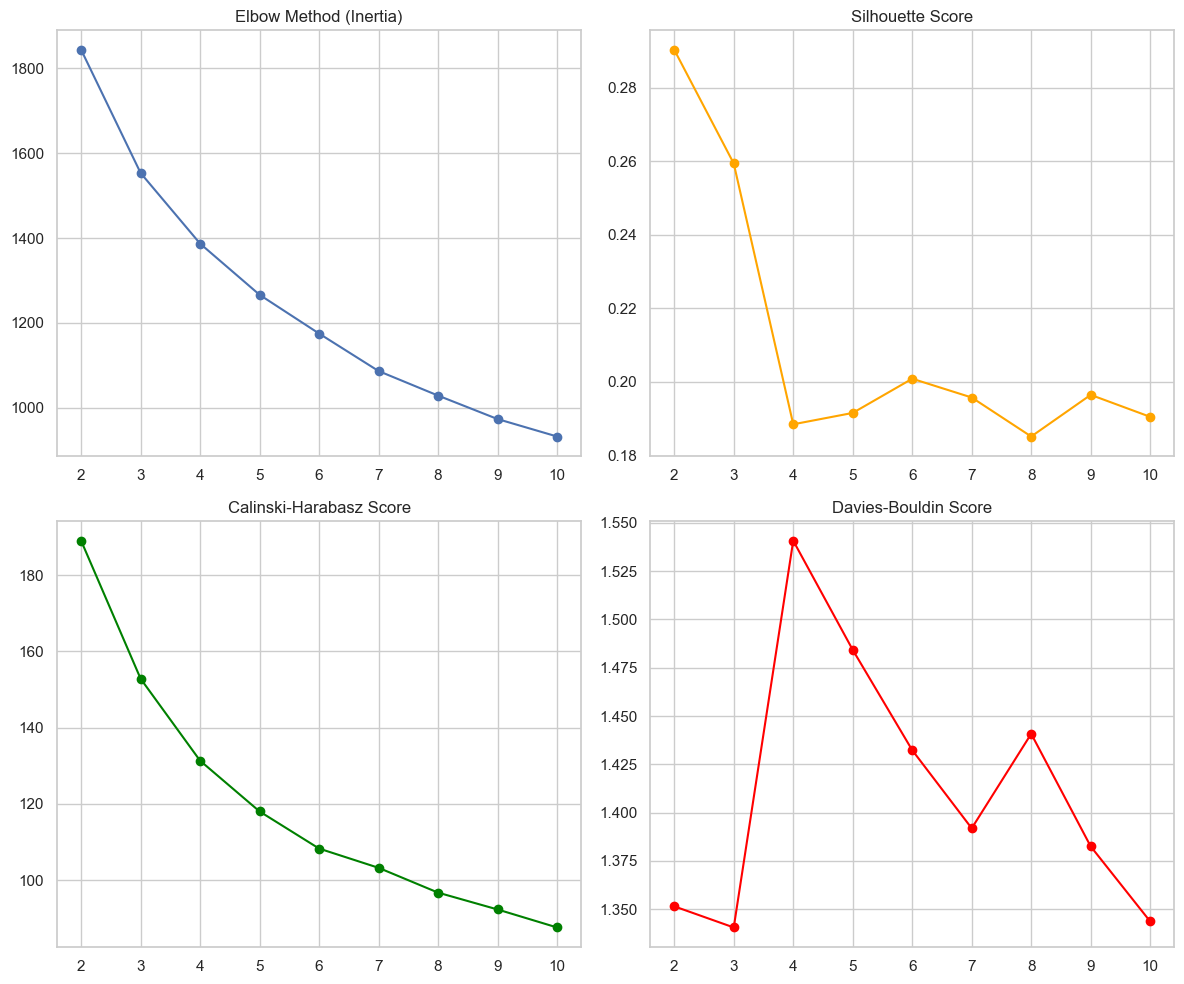

In [4]:
k_range = range(2, 11)
results = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_k = kmeans.fit_predict(features_scaled)
    results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(features_scaled, labels_k),
        'calinski_harabasz': calinski_harabasz_score(features_scaled, labels_k),
        'davies_bouldin': davies_bouldin_score(features_scaled, labels_k)
    })
k_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].plot(k_df['k'], k_df['inertia'], marker='o')
axes[0, 0].set_title('Elbow Method (Inertia)')
axes[0, 1].plot(k_df['k'], k_df['silhouette'], marker='o', color='orange')
axes[0, 1].set_title('Silhouette Score')
axes[1, 0].plot(k_df['k'], k_df['calinski_harabasz'], marker='o', color='green')
axes[1, 0].set_title('Calinski-Harabasz Score')
axes[1, 1].plot(k_df['k'], k_df['davies_bouldin'], marker='o', color='red')
axes[1, 1].set_title('Davies-Bouldin Score')
plt.tight_layout()
plt.show()

## 4. Run Final Clustering Models
I chose `k=4` based on metrics and interpretability.

In [5]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(features_scaled)

hc = AgglomerativeClustering(n_clusters=k_opt, linkage='ward')
hc_labels = hc.fit_predict(features_scaled)

gmm = GaussianMixture(n_components=k_opt, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(features_scaled)

## 5. Cluster Profiles
Analyzing the average original spending per cluster.

                Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0         2809.049180   7061.836066  12349.327869   565.590164   
1        19374.379845   4068.108527   4444.937984  6184.333333   
2         9632.659091   1569.583333   2071.871212  2175.234848   
3        11338.754237  11759.440678  16087.872881  1968.127119   

         Detergents_Paper   Delicassen  
Cluster                                 
0             5342.622951   635.836066  
1              723.325581  2322.713178  
2              345.007576   584.810606  
3             6805.991525  2163.830508  


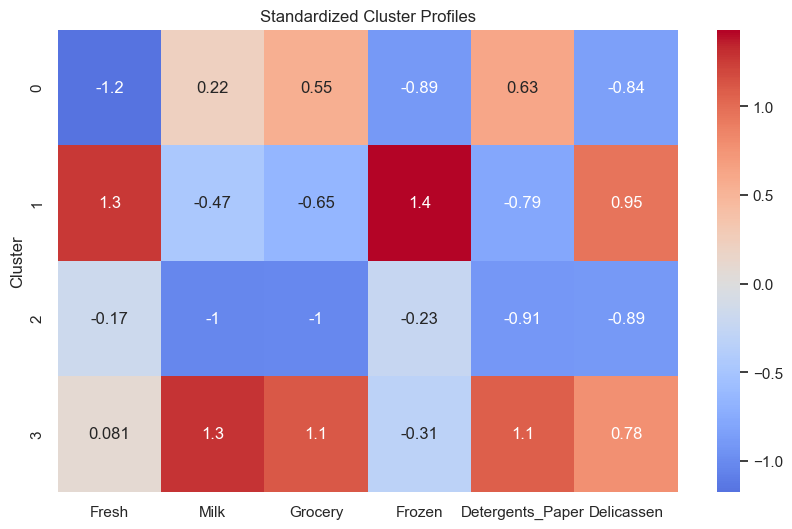

In [6]:
original_features['Cluster'] = kmeans_labels
profiles = original_features.groupby('Cluster').mean()
print(profiles)

plt.figure(figsize=(10, 6))
sns.heatmap((profiles - profiles.mean()) / profiles.std(), annot=True, cmap='coolwarm', center=0)
plt.title('Standardized Cluster Profiles')
plt.show()